<a href="https://colab.research.google.com/github/jadenfang/Moggle/blob/main/Moggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#download dataset
!pip install -q kagglehub
import kagglehub

kagglehub.login()

path = kagglehub.dataset_download("niten19/face-shape-dataset")

#use this if u dont have ur own KGAT_9c1bd60c657c1cd2d4a90ec515fbbb06

print("Dataset downloaded successfully to:", path)

Using Colab cache for faster access to the 'face-shape-dataset' dataset.
Dataset downloaded successfully to: /kaggle/input/face-shape-dataset
Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
#unzip dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join(path, 'FaceShape Dataset', 'training_set')
test_dir = os.path.join(path, 'FaceShape Dataset', 'testing_set')

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_dataset.classes
print("Classes found:", class_names)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Classes found: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Training images: 4000
Testing images: 1000


Training on: cuda
Starting training...
Epoch [1/12] - Loss: 1.3251 - Test Accuracy: 27.20%
   New best model found!
Epoch [2/12] - Loss: 0.9913 - Test Accuracy: 60.20%
   New best model found!
Epoch [3/12] - Loss: 0.7926 - Test Accuracy: 63.40%
   New best model found!
Epoch [4/12] - Loss: 0.6533 - Test Accuracy: 54.20%
Epoch [5/12] - Loss: 0.5833 - Test Accuracy: 70.00%
   New best model found!
Epoch [6/12] - Loss: 0.5478 - Test Accuracy: 76.50%
   New best model found!
Epoch [7/12] - Loss: 0.4717 - Test Accuracy: 77.00%
   New best model found!
Epoch [8/12] - Loss: 0.4392 - Test Accuracy: 74.00%
Epoch [9/12] - Loss: 0.4046 - Test Accuracy: 74.70%
Epoch [10/12] - Loss: 0.3793 - Test Accuracy: 77.20%
   New best model found!
Epoch [11/12] - Loss: 0.3452 - Test Accuracy: 70.10%
Epoch [12/12] - Loss: 0.3109 - Test Accuracy: 78.90%
   New best model found!

🎉 Training Complete! The absolute best accuracy was 78.90%


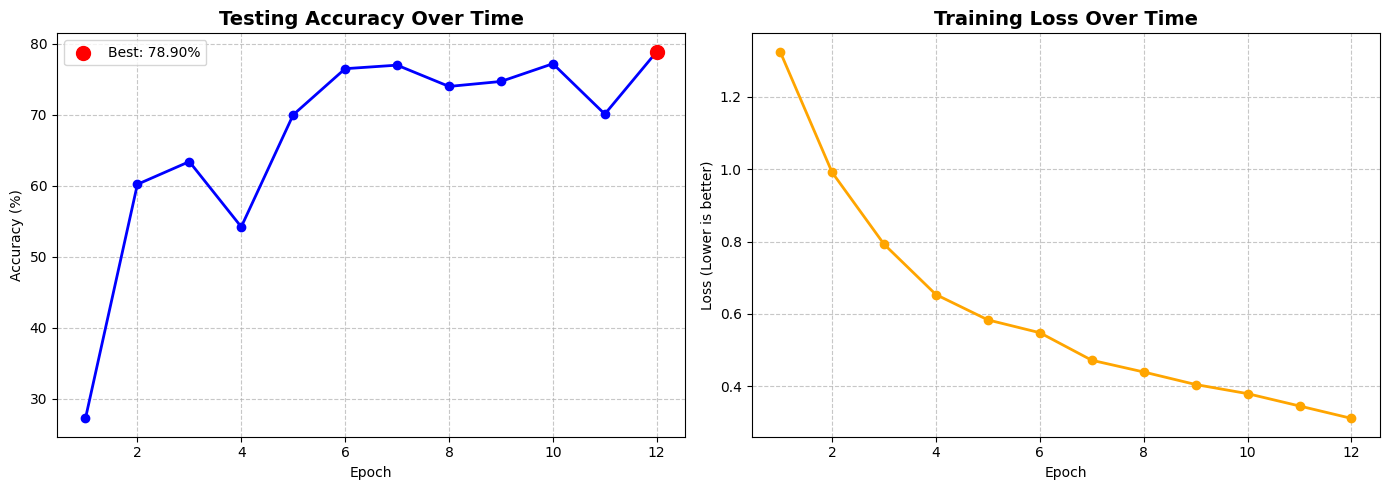

In [5]:
#train model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import ImageFile
import os
import copy
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

#augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join(path, 'FaceShape Dataset', 'training_set')
test_dir = os.path.join(path, 'FaceShape Dataset', 'testing_set')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#set up resnet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 12
best_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

history_accuracy = []
history_loss = []

print("Starting training...")

#train output layer on face shapes
for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    history_loss.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history_accuracy.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_train_loss:.4f} - Test Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_weights = copy.deepcopy(model.state_dict())
        print(f"   New best model found!")

model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'best_face_shape_model.pth')
print(f"\nTraining Complete! The absolute best accuracy was {best_accuracy:.2f}%")

epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_accuracy, marker='o', color='blue', linewidth=2)
plt.title('Testing Accuracy Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)

best_epoch = history_accuracy.index(best_accuracy) + 1
plt.scatter(best_epoch, best_accuracy, color='red', s=100, zorder=5, label=f'Best: {best_accuracy:.2f}%')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_loss, marker='o', color='orange', linewidth=2)
plt.title('Training Loss Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Lower is better)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
#download model
from google.colab import files
files.download('best_face_shape_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

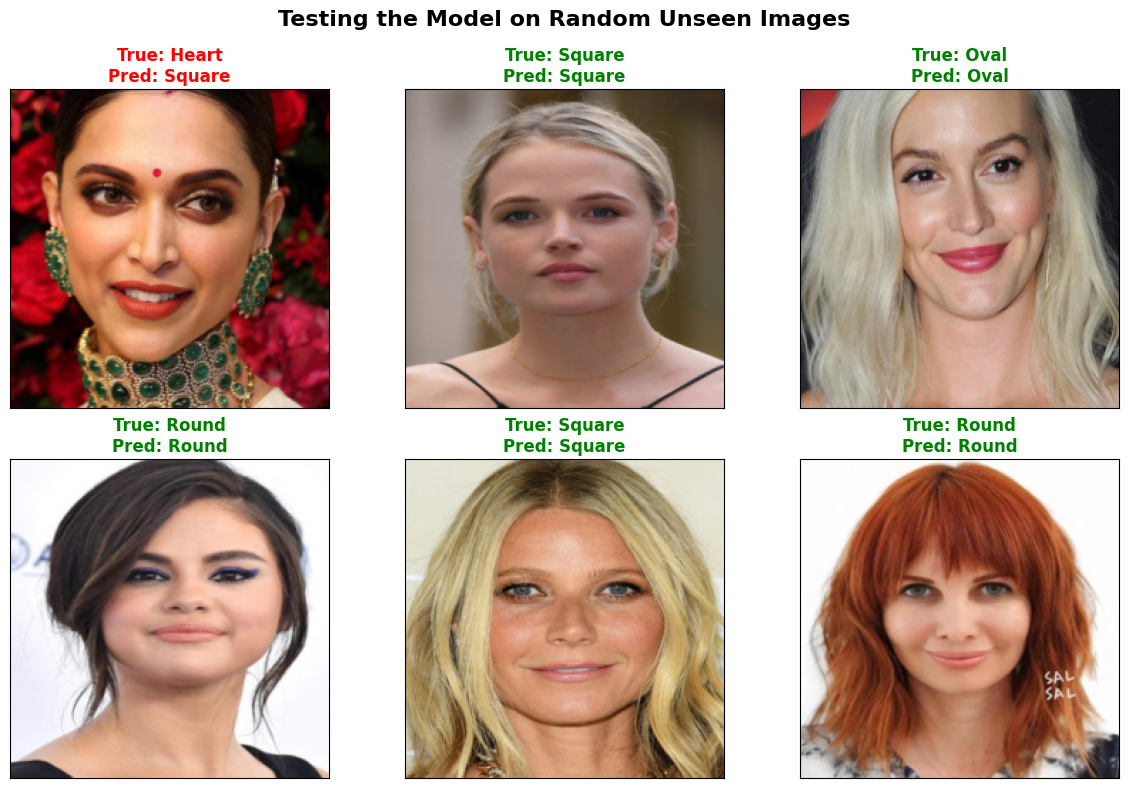

In [6]:
#test model
import matplotlib.pyplot as plt
import numpy as np
import random

model.eval()

num_images = 6
random_indices = random.sample(range(len(test_dataset)), num_images)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Testing the Model on Random Unseen Images", fontsize=16, fontweight='bold')

for i, idx in enumerate(random_indices):
    image_tensor, true_label_idx = test_dataset[idx]

    img_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        _, predicted_idx = torch.max(output, 1)

    true_name = class_names[true_label_idx]
    pred_name = class_names[predicted_idx.item()]

    img_display = image_tensor.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean

    img_display = np.clip(img_display, 0, 1)

    ax = fig.add_subplot(2, 3, i+1, xticks=[], yticks=[])
    ax.imshow(img_display)

    text_color = ("green" if true_name == pred_name else "red")
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=text_color, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Please select an image to upload:


Saving Clavicular_mugshot_March_2026.jpg to Clavicular_mugshot_March_2026.jpg


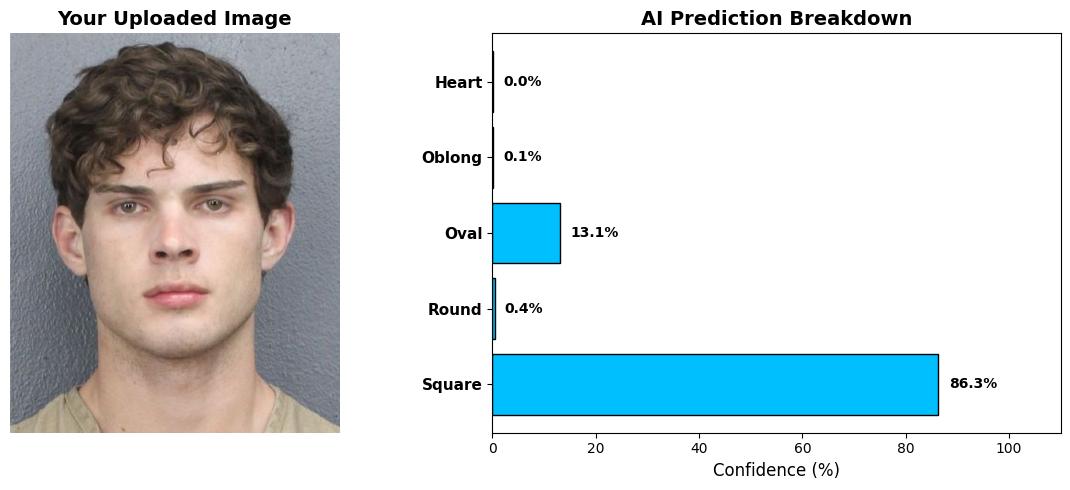

In [7]:
#test with own image
from google.colab import files
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

print("Please select an image to upload:")
uploaded = files.upload()

if len(uploaded) > 0:

    file_name = list(uploaded.keys())[0]

    img = Image.open(file_name).convert('RGB')

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_t = test_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    prob_percentages = [p.item() * 100 for p in probabilities]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title("Your Uploaded Image", fontsize=14, fontweight='bold')

    y_pos = np.arange(len(class_names))
    bars = ax2.barh(y_pos, prob_percentages, align='center', color='deepskyblue', edgecolor='black')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(class_names, fontsize=11, fontweight='bold')
    ax2.invert_yaxis()
    ax2.set_xlabel('Confidence (%)', fontsize=12)
    ax2.set_title('AI Prediction Breakdown', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 110)

    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                 va='center', ha='left', fontsize=10, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

else:
    print("No image was uploaded.")